# Sustainability & ESG Performance Dashboard Project

End-to-end data science workflow:
1. Kaggle API Setup
2. Dataset Download
3. Data Loading
4. Exploratory Data Analysis (EDA)
5. Feature Engineering
6. ESG Insights
7. Machine Learning Model
8. Feature Importance
9. Prepare Data for Dashboard


## Step 1 — Upload Kaggle API Key

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"iakankshasharma","key":"fec2116dc2a85a57624831affa8f47a6"}'}

## Step 2 — Setup Kaggle API

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!pip install kaggle

## Step 3 — Download ESG Dataset

In [ ]:
!kaggle datasets download -d shriyashjagtap/esg-and-financial-performance-dataset
!unzip esg-and-financial-performance-dataset.zip

Dataset URL: https://www.kaggle.com/datasets/shriyashjagtap/esg-and-financial-performance-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
100% 379k/379k [00:00<00:00, 88.4MB/s]

Archive:  esg-and-financial-performance-dataset.zip
  inflating: company_esg_financial_dataset.csv  


## Step 4 — Load Dataset

In [ ]:
import pandas as pd

df = pd.read_csv('company_esg_financial_dataset.csv')
df.head()

,CompanyID,CompanyName,Industry,Region,Year,Revenue,ProfitMargin,MarketCap,GrowthRate,ESG_Overall,ESG_Environmental,ESG_Social,ESG_Governance,CarbonEmissions,WaterUsage,EnergyConsumption
0,1,Company_1,Retail,Latin America,2015,459.2,6.0,337.5,NaN,57.0,60.7,33.5,76.8,35577.4,17788.7,71154.7
1,1,Company_1,Retail,Latin America,2016,473.8,4.6,366.6,3.2,56.7,58.9,32.8,78.5,37314.7,18657.4,74629.4
2,1,Company_1,Retail,Latin America,2017,564.9,5.2,313.4,19.2,56.5,57.6,34.0,77.8,45006.4,22503.2,90012.9
3,1,Company_1,Retail,Latin America,2018,558.4,4.3,283.0,-1.1,58.0,62.3,33.4,78.3,42650.1,21325.1,85300.2
4,1,Company_1,Retail,Latin America,2019,554.5,4.9,538.1,-0.7,56.6,63.7,30.0,76.1,41799.4,20899.7,83598.8


## Step 5 — Dataset Overview

In [ ]:
df.shape
df.columns
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11000 entries, 0 to 10999
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CompanyID          11000 non-null  int64  
 1   CompanyName        11000 non-null  object 
 2   Industry           11000 non-null  object 
 3   Region             11000 non-null  object 
 4   Year               11000 non-null  int64  
 5   Revenue            11000 non-null  float64
 6   ProfitMargin       11000 non-null  float64
 7   MarketCap          11000 non-null  float64
 8   GrowthRate         10000 non-null  float64
 9   ESG_Overall        11000 non-null  float64
 10  ESG_Environmental  11000 non-null  float64
 11  ESG_Social         11000 non-null  float64
 12  ESG_Governance     11000 non-null  float64
 13  CarbonEmissions    11000 non-null  float64
 14  WaterUsage         11000 non-null  float64
 15  EnergyConsumption  11000 non-null  float64
dtypes: float64(11), int64(

,CompanyID,Year,Revenue,ProfitMargin,MarketCap,GrowthRate,ESG_Overall,ESG_Environmental,ESG_Social,ESG_Governance,CarbonEmissions,WaterUsage,EnergyConsumption
count,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,10000.000000,11000.000000,11000.000000,11000.000000,11000.000000,1.100000e+04,1.100000e+04,1.100000e+04
mean,500.500000,2020.000000,4670.850591,10.900455,13380.622236,4.830370,54.615273,56.416991,55.660582,51.767655,1.271462e+06,5.600442e+05,1.165839e+07
std,288.688113,3.162421,9969.954369,8.758711,39922.870373,9.424787,15.893937,26.767233,23.356152,25.323370,5.067760e+06,1.565686e+06,5.095836e+07
min,1.000000,2015.000000,35.900000,-20.000000,1.800000,-36.000000,6.300000,0.000000,0.000000,0.000000,2.042200e+03,1.021100e+03,5.105500e+03
25%,250.750000,2017.000000,938.775000,5.300000,1098.525000,-1.325000,44.100000,34.700000,37.600000,30.775000,1.228530e+05,6.488467e+04,3.069161e+05
50%,500.500000,2020.000000,1902.300000,10.500000,3096.450000,4.900000,54.600000,55.600000,55.150000,52.100000,2.920734e+05,2.038805e+05,1.221745e+06
75%,750.250000,2023.000000,4342.625000,16.300000,9995.500000,11.000000,65.600000,79.000000,73.800000,73.000000,7.407311e+05,5.251880e+05,5.616437e+06
max,1000.000000,2025.000000,180810.400000,50.000000,865271.700000,38.000000,98.800000,100.000000,100.000000,100.000000,1.741047e+08,5.223142e+07,1.741047e+09


## Step 6 — ESG Score Distribution

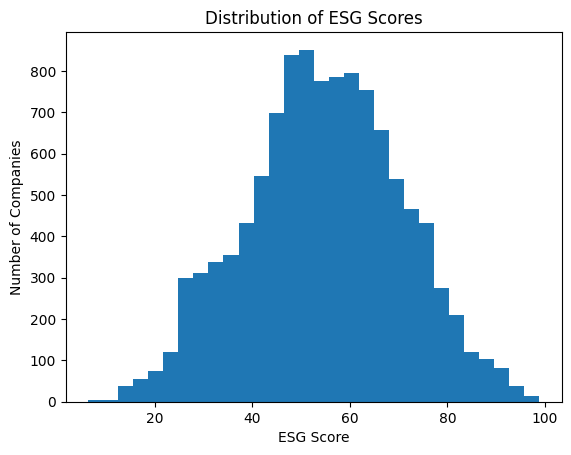

In [ ]:
import matplotlib.pyplot as plt

plt.hist(df['ESG_Overall'], bins=30)
plt.title('Distribution of ESG Scores')
plt.xlabel('ESG Score')
plt.ylabel('Number of Companies')
plt.show()

## Step 7 — ESG vs Carbon Emissions

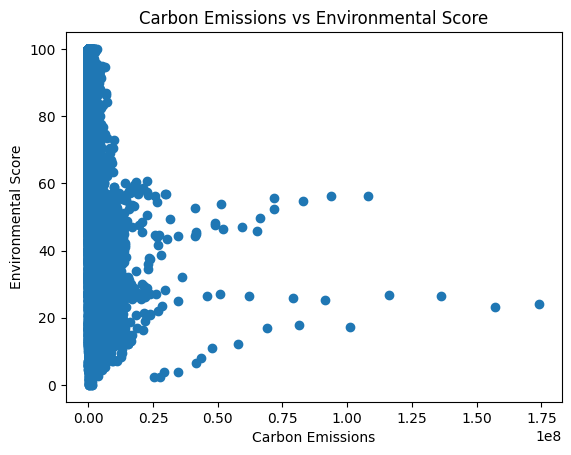

In [ ]:
plt.scatter(df['CarbonEmissions'], df['ESG_Environmental'])
plt.xlabel('Carbon Emissions')
plt.ylabel('Environmental Score')
plt.title('Carbon Emissions vs Environmental Score')
plt.show()

## Step 8 — Feature Engineering

In [ ]:
df['CarbonEfficiency'] = df['Revenue'] / df['CarbonEmissions']
df['EnergyEfficiency'] = df['Revenue'] / df['EnergyConsumption']

df['Calculated_ESG'] = (
    df['ESG_Environmental'] +
    df['ESG_Social'] +
    df['ESG_Governance']
) / 3

In [ ]:
def esg_category(score):
    if score >= 75:
        return 'Leader'
    elif score >= 50:
        return 'Average'
    else:
        return 'Lagging'

df['SustainabilityCategory'] = df['ESG_Overall'].apply(esg_category)
df.head()

,CompanyID,CompanyName,Industry,Region,Year,Revenue,ProfitMargin,MarketCap,GrowthRate,ESG_Overall,ESG_Environmental,ESG_Social,ESG_Governance,CarbonEmissions,WaterUsage,EnergyConsumption,CarbonEfficiency,EnergyEfficiency,Calculated_ESG,SustainabilityCategory
0,1,Company_1,Retail,Latin America,2015,459.2,6.0,337.5,NaN,57.0,60.7,33.5,76.8,35577.4,17788.7,71154.7,0.012907,0.006454,57.000000,Average
1,1,Company_1,Retail,Latin America,2016,473.8,4.6,366.6,3.2,56.7,58.9,32.8,78.5,37314.7,18657.4,74629.4,0.012697,0.006349,56.733333,Average
2,1,Company_1,Retail,Latin America,2017,564.9,5.2,313.4,19.2,56.5,57.6,34.0,77.8,45006.4,22503.2,90012.9,0.012552,0.006276,56.466667,Average
3,1,Company_1,Retail,Latin America,2018,558.4,4.3,283.0,-1.1,58.0,62.3,33.4,78.3,42650.1,21325.1,85300.2,0.013093,0.006546,58.000000,Average
4,1,Company_1,Retail,Latin America,2019,554.5,4.9,538.1,-0.7,56.6,63.7,30.0,76.1,41799.4,20899.7,83598.8,0.013266,0.006633,56.600000,Average


## Step 9 — ESG Insights

In [ ]:
top_companies = df.sort_values('ESG_Overall', ascending=False).head(10)
top_companies[['CompanyName','Industry','Region','ESG_Overall']]

,CompanyName,Industry,Region,ESG_Overall
5255,Company_478,Finance,Europe,98.8
5256,Company_478,Finance,Europe,98.3
5252,Company_478,Finance,Europe,98.2
5257,Company_478,Finance,Europe,98.0
5254,Company_478,Finance,Europe,97.8
5253,Company_478,Finance,Europe,97.7
5251,Company_478,Finance,Europe,96.9
5250,Company_478,Finance,Europe,96.7
5189,Company_472,Healthcare,Europe,96.3
3877,Company_353,Finance,Europe,96.0


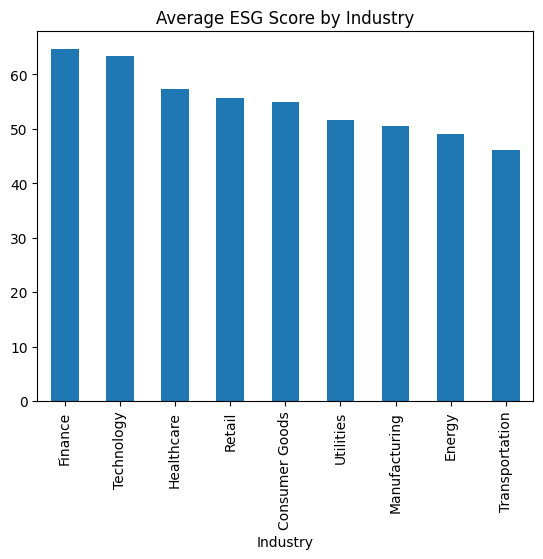

In [ ]:
industry_esg = df.groupby('Industry')['ESG_Overall'].mean().sort_values(ascending=False)
industry_esg.plot(kind='bar', title='Average ESG Score by Industry')
plt.show()

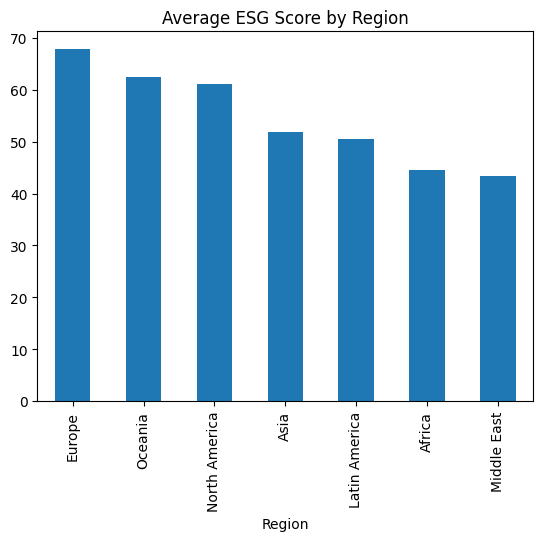

In [ ]:
region_esg = df.groupby('Region')['ESG_Overall'].mean().sort_values(ascending=False)
region_esg.plot(kind='bar', title='Average ESG Score by Region')
plt.show()

## Step 10 — Machine Learning Model

In [ ]:
from sklearn.model_selection import train_test_split

features = [
    "Revenue",
    "ProfitMargin",
    "MarketCap",
    "GrowthRate",
    "CarbonEmissions",
    "EnergyConsumption",
    "WaterUsage",
    "ESG_Environmental",
    "ESG_Social",
    "ESG_Governance"
]

X = df[features]
y = df["ESG_Overall"]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print('MSE:', mse)
print('R2 Score:', r2)

MSE: 0.6295853274999988
R2 Score: 0.997332679281953


## Step 11 — Feature Importance

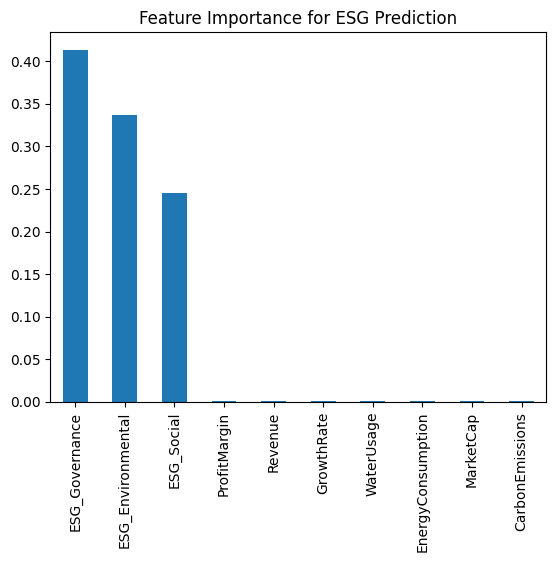

In [ ]:
importance = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)
importance.plot(kind='bar', title='Feature Importance for ESG Prediction')
plt.show()

## Step 12 — Save Processed Dataset
This will be used later for the Streamlit dashboard.

In [ ]:
df.to_csv('processed_esg_data.csv', index=False)
print('Processed dataset saved.')

Processed dataset saved.
